# Berka — empirical baseline

Empirical baseline on the Berka dataset, with activity and attractiveness measured as **transactions per active month** rather than as raw counts over the 6-year panel. Accounts join throughout the panel, so a late-joining account would otherwise look artificially low-activity; we define each account's active span as `(end_of_obs − first_date)` in months, so dormant-late behavior shows up as a lower rate but late-joining behavior doesn't.

The notebook is structured around the model's logical flow:

1. **Stage** — what the dataset looks like (balance trajectories).
2. **Inputs** — what the simulator needs to be told: spending propensity $h(s)$, within-account dispersion $\hat\xi$, activity/attractiveness degree marginals (per active month), and the copula linking them.
3. **Conditional** — a binned check on $P(m\mid s)$.
4. **Outputs** — what the simulator's outputs should look like: $P(m)$, $P(w)$, the joint $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ and $(\mathrm{vol}_\mathrm{in}, \mathrm{vol}_\mathrm{out})$ scatters, and the per-transaction $q$ distribution as a diagnostic.
5. **Simulator validation** — Beta-Binomial simulator vs Berka empirical $P(m)$, $P(w)$, plus a data-driven bootstrap test.
6. **Calibration summary** — single-cell printout of all numbers.

Comparison foil throughout: **Poisson** (the literature's unexamined null). Beta-Binomial $\hat\xi$ is reported for direct calibration of the simulator's dispersion parameter.

**Inputs**: `berka-dataset/trans-clean-eng.asc` plus `account.asc`, `disp.asc`, `client.asc`, `district.asc`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

DATA_DIR = 'berka-dataset'
TX_PATH = os.path.join(DATA_DIR, 'trans-clean-eng.asc')

VOLUNTARY_CATEGS = {'Withdrawal', 'Transfer', 'Card Payment'}

plt.rcParams.update({'figure.dpi': 100, 'axes.labelsize': 12, 'legend.fontsize': 10})

import pathlib
FIG_DIR = pathlib.Path('figs'); FIG_DIR.mkdir(exist_ok=True)
def save_fig(name):
    plt.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')


In [2]:
from scipy.stats import poisson as _poisson_dist
from scipy.stats import lognorm as _lognorm_dist
from scipy.stats import nbinom as _nbinom_dist

def histogram(values, num_bins=30, log_bin=False, density=True):
    """Return (bin_centers, density) for a 1D array."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if log_bin:
        v = v[v > 0]
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.logspace(np.log10(v.min()), np.log10(v.max()), num_bins + 1)
    else:
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.linspace(v.min(), v.max(), num_bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=density)
    centers = np.sqrt(edges[:-1] * edges[1:]) if log_bin else 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


def fit_powerlaw_tail(centers, density, x_min):
    """Least-squares fit of log p = -alpha * log x + C on log-log, for centers >= x_min."""
    keep = (centers >= x_min) & (density > 0) & np.isfinite(density)
    if keep.sum() < 3:
        return np.nan, np.nan
    slope, intercept = np.polyfit(np.log(centers[keep]), np.log(density[keep]), 1)
    return -slope, intercept


def sample_s_empirical(n_target, s_values, seed=0):
    """Sample n_target spending rates from the empirical CDF via inverse-CDF interpolation.

    Use this when the simulator wants more nodes than Berka's 4,500 — the empirical h(s) is
    used as a generative distribution rather than treating it as a fixed list.
    """
    rng = np.random.default_rng(seed)
    sorted_s = np.sort(np.asarray(s_values))
    sorted_s = sorted_s[np.isfinite(sorted_s)]
    cdf_grid = (np.arange(len(sorted_s)) + 0.5) / len(sorted_s)
    u = rng.uniform(0, 1, size=n_target)
    return np.interp(u, cdf_grid, sorted_s)


## Load and preprocess

Build a `berka` dict (`transactions`, `agents`, `balance_pivot`, `filtered_balances`) so figure code is portable across datasets.


In [3]:
tx = pd.read_csv(
    TX_PATH, sep=';',
    dtype={'trans_id': 'int64', 'account_id': 'int32', 'date': 'string',
           'type': 'category', 'amount': 'float64', 'balance': 'float64',
           'bank': 'string', 'account': 'string', 'value': 'float64',
           'categ': 'category', 'detail': 'string'},
)
tx['date'] = pd.to_datetime(tx['date'], format='%y%m%d')
tx = tx.sort_values(['account_id', 'date', 'trans_id']).reset_index(drop=True)
tx['pre_balance'] = tx['balance'] - tx['value']
print(f'{len(tx):,} transactions across {tx.account_id.nunique():,} accounts; {tx.date.min().date()} – {tx.date.max().date()}')
tx.head()

1,056,320 transactions across 4,500 accounts; 1993-01-01 – 1998-12-31


,trans_id,account_id,date,type,amount,balance,bank,account,value,categ,detail,pre_balance
0,1,1,1995-03-24,CREDIT,1000.0,1000.0,<NA>,<NA>,1000.0,Deposit,<NA>,0.0
1,5,1,1995-04-13,CREDIT,3679.0,4679.0,AB,41403269,3679.0,Transfer,<NA>,1000.0
2,199,1,1995-04-23,CREDIT,12600.0,17279.0,<NA>,<NA>,12600.0,Deposit,<NA>,4679.0
3,3530438,1,1995-04-30,CREDIT,19.2,17298.2,<NA>,<NA>,19.2,Fee,Interest,17279.0
4,6,1,1995-05-13,CREDIT,3679.0,20977.2,AB,41403269,3679.0,Transfer,<NA>,17298.2


In [4]:
is_debit  = tx['type'].eq('DEBIT')
is_credit = tx['type'].eq('CREDIT')

tx['frac_out'] = np.where(is_debit & (tx['pre_balance'] > 0),
                          tx['amount'] / tx['pre_balance'], np.nan)
tx['frac_in']  = np.where(is_credit & (tx['pre_balance'] >= 0),
                          tx['amount'] / (tx['pre_balance'] + tx['amount']), np.nan)

# 'voluntary' = excludes bank-generated Fee transactions (interest credits AND service charges).
# Defined symmetrically for both directions so we can compare voluntary inflows vs outflows
# on equal footing (a closed-system model implicitly assumes P(w_in) = P(w_out)).
tx['voluntary'] = tx['categ'] != 'Fee'

n_overdraft = (tx['frac_out'] > 1).sum()
tx.loc[tx['frac_out'] > 1, 'frac_out'] = np.nan
print(f'frac_out defined on {tx["frac_out"].notna().sum():,} debits ({n_overdraft:,} overdrafts dropped)')
print(f'voluntary (non-Fee) transactions: {tx["voluntary"].sum():,}'
      f'   — DEBIT vol: {(tx["voluntary"] & is_debit).sum():,};'
      f'   CREDIT vol: {(tx["voluntary"] & is_credit).sum():,}')


frac_out defined on 648,839 debits (869 overdrafts dropped)
voluntary (non-Fee) transactions: 715,797   — DEBIT vol: 493,828;   CREDIT vol: 221,969


In [5]:
amt_credit     = tx['amount'].where(tx['type'].eq('CREDIT'), 0.0)
amt_debit      = tx['amount'].where(tx['type'].eq('DEBIT'),  0.0)
amt_credit_vol = tx['amount'].where(tx['type'].eq('CREDIT') & tx['voluntary'], 0.0)
amt_debit_vol  = tx['amount'].where(tx['type'].eq('DEBIT')  & tx['voluntary'], 0.0)
n_credit       = tx['type'].eq('CREDIT').astype('int32')
n_debit        = tx['type'].eq('DEBIT').astype('int32')
n_credit_vol   = (tx['type'].eq('CREDIT') & tx['voluntary']).astype('int32')
n_debit_vol    = (tx['type'].eq('DEBIT')  & tx['voluntary']).astype('int32')
frac_vol       = tx['frac_out'].where(tx['voluntary'])

g_aid = tx['account_id']
agents = pd.DataFrame({
    'vol_in':       amt_credit.groupby(g_aid, observed=True).sum(),
    'vol_out':      amt_debit.groupby(g_aid,  observed=True).sum(),
    'vol_in_vol':   amt_credit_vol.groupby(g_aid, observed=True).sum(),
    'vol_out_vol':  amt_debit_vol.groupby(g_aid,  observed=True).sum(),
    'tx_in':        n_credit.groupby(g_aid, observed=True).sum(),
    'tx_out':       n_debit.groupby(g_aid,  observed=True).sum(),
    'tx_in_vol':    n_credit_vol.groupby(g_aid, observed=True).sum(),
    'tx_out_vol':   n_debit_vol.groupby(g_aid,  observed=True).sum(),
    'mean_frac_out_all':       tx.groupby('account_id', observed=True)['frac_out'].mean(),
    'mean_frac_out_voluntary': frac_vol.groupby(g_aid, observed=True).mean(),
    'initial_bal':  tx.groupby('account_id', observed=True)['balance'].first(),
    'final_bal':    tx.groupby('account_id', observed=True)['balance'].last(),
    'min_bal':      tx.groupby('account_id', observed=True)['balance'].min(),
    'mean_bal':     tx.groupby('account_id', observed=True)['balance'].mean(),
    'first_date':   tx.groupby('account_id', observed=True)['date'].first(),
    'last_date':    tx.groupby('account_id', observed=True)['date'].last(),
})

# Rate variant: months each account was "active" = global end-of-window minus account's
# first transaction, in months. Late-joiners get a shorter active span, so dividing their
# count by months_active gives a rate comparable to early-joiners.
end_of_obs = tx['date'].max()
agents['months_active'] = (end_of_obs - agents['first_date']).dt.days / 30.0
# Guard against degenerate spans (first txn on the very last day): force >= 1 day.
agents['months_active'] = agents['months_active'].clip(lower=1.0 / 30.0)

agents['tx_in_rate']      = agents['tx_in']      / agents['months_active']
agents['tx_out_rate']     = agents['tx_out']     / agents['months_active']
agents['tx_in_vol_rate']  = agents['tx_in_vol']  / agents['months_active']
agents['tx_out_vol_rate'] = agents['tx_out_vol'] / agents['months_active']
# Total transaction rate (in + out, all types) — used by the activity filter in the next cell.
agents['tx_total_rate']   = (agents['tx_in'] + agents['tx_out']) / agents['months_active']

print(agents.shape)
print(f"end_of_obs = {end_of_obs.date()};  months_active "
      f"range [{agents['months_active'].min():.2f}, {agents['months_active'].max():.2f}], "
      f"mean = {agents['months_active'].mean():.2f}")
agents.head()


(4500, 22)
end_of_obs = 1998-12-31;  months_active range [12.23, 73.00], mean = 41.36


,vol_in,vol_out,vol_in_vol,vol_out_vol,tx_in,tx_out,tx_in_vol,tx_out_vol,mean_frac_out_all,mean_frac_out_voluntary,...,min_bal,mean_bal,first_date,last_date,months_active,tx_in_rate,tx_out_rate,tx_in_vol_rate,tx_out_vol_rate,tx_total_rate
account_id,,,,,,,,,,,,,,,,,,,,,
1,194320.5,180854.0,191255.0,180270.0,102,137,57,97,0.078942,0.111116,...,1000.0,15994.008368,1995-03-24,1998-12-31,45.933333,2.220610,2.982583,1.240929,2.111756,5.203193
2,1597053.5,1554425.8,1586336.0,1553476.8,152,326,82,261,0.123065,0.153604,...,1100.0,36540.704393,1993-02-26,1998-12-31,71.133333,2.136832,4.582943,1.152765,3.669166,6.719775
3,173059.0,121962.8,170989.0,121773.0,46,71,28,58,0.069980,0.085537,...,1000.0,26973.506838,1997-07-07,1998-12-31,18.066667,2.546125,3.929889,1.549815,3.210332,6.476015
4,192346.0,158625.4,189602.0,158202.0,65,121,35,92,0.059758,0.078375,...,800.0,21753.446237,1996-02-21,1998-12-31,34.800000,1.867816,3.477011,1.005747,2.643678,5.344828
5,97485.0,69396.4,95923.0,69192.0,35,49,20,35,0.052975,0.073941,...,600.0,25090.069048,1997-05-30,1998-12-31,19.333333,1.810345,2.534483,1.034483,1.810345,4.344828


In [6]:
account = pd.read_csv(os.path.join(DATA_DIR, 'account.asc'), sep=';')
disp    = pd.read_csv(os.path.join(DATA_DIR, 'disp.asc'),    sep=';')
client  = pd.read_csv(os.path.join(DATA_DIR, 'client.asc'),  sep=';', dtype={'birth_number': 'string'})
district = pd.read_csv(os.path.join(DATA_DIR, 'district.asc'), sep=';')

owners = disp[disp['type'] == 'OWNER'].merge(client, on='client_id', how='left')
bn = owners['birth_number'].str.zfill(6)
month = bn.str[2:4].astype(int)
owners['gender'] = np.where(month > 50, 'F', 'M')
owners = owners[['account_id', 'gender']]

district = district.rename(columns={'A1': 'district_id', 'A3': 'region', 'A8': 'city_category', 'A10': 'avg_salary_pct'})
acct_meta = (account[['account_id', 'district_id']]
             .merge(district[['district_id', 'region', 'city_category', 'avg_salary_pct']], on='district_id', how='left')
             .merge(owners, on='account_id', how='left'))
agents = agents.join(acct_meta.set_index('account_id'))
agents.head()

,vol_in,vol_out,vol_in_vol,vol_out_vol,tx_in,tx_out,tx_in_vol,tx_out_vol,mean_frac_out_all,mean_frac_out_voluntary,...,tx_in_rate,tx_out_rate,tx_in_vol_rate,tx_out_vol_rate,tx_total_rate,district_id,region,city_category,avg_salary_pct,gender
account_id,,,,,,,,,,,,,,,,,,,,,
1,194320.5,180854.0,191255.0,180270.0,102,137,57,97,0.078942,0.111116,...,2.220610,2.982583,1.240929,2.111756,5.203193,18,south Bohemia,1,65.3,F
2,1597053.5,1554425.8,1586336.0,1553476.8,152,326,82,261,0.123065,0.153604,...,2.136832,4.582943,1.152765,3.669166,6.719775,1,Prague,1,100.0,M
3,173059.0,121962.8,170989.0,121773.0,46,71,28,58,0.069980,0.085537,...,2.546125,3.929889,1.549815,3.210332,6.476015,5,central Bohemia,1,51.4,M
4,192346.0,158625.4,189602.0,158202.0,65,121,35,92,0.059758,0.078375,...,1.867816,3.477011,1.005747,2.643678,5.344828,12,central Bohemia,1,58.0,M
5,97485.0,69396.4,95923.0,69192.0,35,49,20,35,0.052975,0.073941,...,1.810345,2.534483,1.034483,1.810345,4.344828,15,south Bohemia,1,51.9,M


In [7]:
# --- Filter out negligible-balance / negligible-activity accounts ---
# The full Berka population shows secondary low-end humps in P(m), tx_out, and tx_in caused
# by accounts with negligible balance / activity (likely dormant or opened-and-closed during
# the observation window). The count-variant notebook filtered on **mean balance** since this
# is closest to the model's physical framing -- each node carries m random walkers, and
# accounts with vanishingly small m contribute essentially nothing to the system dynamics.
# Here, with rates instead of counts, the low-end peaks in both activity marginals come from
# accounts averaging less than one transaction per active month in one direction or the
# other. So we filter on BOTH `tx_in_rate >= 1` and `tx_out_rate >= 1` -- consistent with
# what the Sarafu calibration does, adapted to Berka's longer panel and clear monthly
# periodicity (salary in, paychecks out, ~once per month).
#
# CZK/USD averaged ~29 across 1993-1998 (range 26.5 in 1995 to 32.3 in 1998), so:
#   1000 Kč ≈ $34 USD — "above pocket-change" bar
#   5000 Kč ≈ $170 USD — clearly a working account
CZK_PER_USD_MEAN = 29.0
ACTIVE_BAL_CZK = 1000

# Compare a few candidate filter criteria — useful for tuning.
n_total = len(agents)
print(f'Candidate filters (CZK 1993-1998, ~{CZK_PER_USD_MEAN:.0f} CZK/USD):')
for col, thr in [
    ('mean_bal',       500),
    ('mean_bal',       1000),
    ('vol_out',        30_000),
    ('vol_out',        50_000),
    ('tx_in_rate',     0.5),
    ('tx_in_rate',     1.0),
    ('tx_out_rate',    0.5),
    ('tx_out_rate',    1.0),
    ('tx_total_rate',  1.0),
]:
    n_kept = int((agents[col] >= thr).sum())
    units = 'Kč' if col in ('mean_bal', 'vol_out') else ('tx/mo' if col.endswith('_rate') else 'tx')
    usd = f' (≈${thr/CZK_PER_USD_MEAN:.0f})' if units == 'Kč' else ''
    print(f'  {col:14s} >= {thr:>8} {units}{usd}:  keep {n_kept:,}/{n_total:,}'
          f'  (drop {n_total-n_kept:,}, {(1-n_kept/n_total)*100:.1f}%)')

# --- Apply the chosen filter ---
# Two criteria combined:
#  - vol_out >= 30,000 Kč: "moved real money" — drops the dormant low-balance subpopulation
#  - tx_in_rate >= 1 AND tx_out_rate >= 1: at least one transaction per active month
#    in each direction. Drops the low-end rate spikes that throw off the degree-marginal
#    plots (in either direction) and is consistent with the Sarafu setup.
ACTIVE_VOL_CZK    = 30_000     # ~$1,000 over 6 years (~$170/yr)
ACTIVE_RATE_TXMO  = 1.0        # at least one tx/month in each direction over the active span
active = (
    (agents['vol_out']      >= ACTIVE_VOL_CZK) &
    (agents['tx_in_rate']   >= ACTIVE_RATE_TXMO) &
    (agents['tx_out_rate']  >= ACTIVE_RATE_TXMO)
)
n_total_tx = len(tx)
agents = agents[active].copy()
tx = tx[tx['account_id'].isin(agents.index)].copy()
print(f"\nApplied: vol_out >= {ACTIVE_VOL_CZK:,} Kč  AND  tx_in_rate >= {ACTIVE_RATE_TXMO}  AND  tx_out_rate >= {ACTIVE_RATE_TXMO}")
print(f"  accounts: {n_total - len(agents):,} dropped / {len(agents):,} kept")
print(f"  transactions: {n_total_tx - len(tx):,} dropped / {len(tx):,} kept")


Candidate filters (CZK 1993-1998, ~29 CZK/USD):
  mean_bal       >=      500 Kč (≈$17):  keep 4,500/4,500  (drop 0, 0.0%)
  mean_bal       >=     1000 Kč (≈$34):  keep 4,500/4,500  (drop 0, 0.0%)
  vol_out        >=    30000 Kč (≈$1034):  keep 4,427/4,500  (drop 73, 1.6%)
  vol_out        >=    50000 Kč (≈$1724):  keep 4,345/4,500  (drop 155, 3.4%)
  tx_in_rate     >=      0.5 tx/mo:  keep 4,479/4,500  (drop 21, 0.5%)
  tx_in_rate     >=      1.0 tx/mo:  keep 4,434/4,500  (drop 66, 1.5%)
  tx_out_rate    >=      0.5 tx/mo:  keep 4,419/4,500  (drop 81, 1.8%)
  tx_out_rate    >=      1.0 tx/mo:  keep 4,382/4,500  (drop 118, 2.6%)
  tx_total_rate  >=      1.0 tx/mo:  keep 4,463/4,500  (drop 37, 0.8%)

Applied: vol_out >= 30,000 Kč  AND  tx_in_rate >= 1.0  AND  tx_out_rate >= 1.0
  accounts: 139 dropped / 4,361 kept
  transactions: 6,607 dropped / 1,049,713 kept


In [8]:
eod = (tx.groupby(['account_id', 'date'])['balance'].last()
         .unstack('account_id').sort_index())
full_idx = pd.date_range(eod.index.min(), eod.index.max(), freq='D')
balance_pivot = eod.reindex(full_idx).ffill().T
balance_pivot.index.name = 'account_id'
balance_pivot.columns.name = 'date'
print(f'balance_pivot: {balance_pivot.shape[0]:,} accounts × {balance_pivot.shape[1]:,} days')

fb = balance_pivot.stack().rename('balance').reset_index()
filtered_balances = fb[fb['balance'] >= 1].copy()
print(f'filtered_balances: {len(filtered_balances):,} (account, day) cells with balance ≥ 1')

balance_pivot: 4,361 accounts × 2,191 days
filtered_balances: 5,436,849 (account, day) cells with balance ≥ 1


In [9]:
berka = {
    'transactions':       tx,
    'agents':             agents,
    'balance_pivot':      balance_pivot,
    'filtered_balances':  filtered_balances,
}

# Sanity checks
assert berka['agents'].shape[0] > 0
assert berka['agents'].shape[0] <= 4500, berka['agents'].shape
print(f"berka['agents']: {berka['agents'].shape[0]:,} accounts (after dormant filter)")

f = berka['transactions']['frac_out'].dropna()
assert f.between(0, 1).all(), (f.min(), f.max())

first_value = tx.groupby('account_id', observed=True)['value'].first()
identity_lhs = agents['vol_in'].sum() - agents['vol_out'].sum()
identity_rhs = (agents['final_bal'] - (agents['initial_bal'] - first_value)).sum()
rel_err = abs(identity_lhs - identity_rhs) / abs(identity_lhs)
print(f'flow identity rel-error: {rel_err:.2%}')
assert rel_err < 0.01, (identity_lhs, identity_rhs)


berka['agents']: 4,361 accounts (after dormant filter)
flow identity rel-error: 0.44%


## 1. Stage — balance trajectories

Random ~1% of accounts. Sets the visual character of the dataset before any aggregation: most accounts are roughly stationary, a few have large excursions, and the typical scale is ~10⁴–10⁵ Kč.

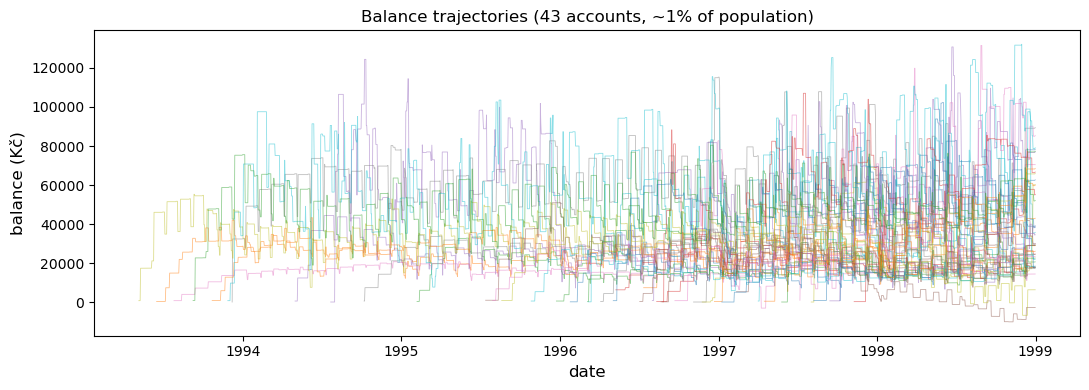

In [10]:
rng = np.random.default_rng(42)
sample = rng.choice(balance_pivot.index, size=max(1, balance_pivot.shape[0] // 100), replace=False)
fig, ax = plt.subplots(figsize=(11, 4))
for acct in sample:
    ax.plot(balance_pivot.columns, balance_pivot.loc[acct].values, lw=0.6, alpha=0.5)
ax.set_xlabel('date'); ax.set_ylabel('balance (Kč)')
ax.set_title(f'Balance trajectories ({len(sample)} accounts, ~1% of population)')
fig.tight_layout()
save_fig('balance_trajectories')


## 2. Inputs — what the simulator needs

Each subsection below characterizes one ingredient and reports the calibration number(s) needed for the simulator. Entire section is empirical.

### 2.1 $h(s)$ — distribution of spending rates

Two parametric simulator-feed options for $h(s)$ on $[s_{\min}, s_{\max}]$:

**(A) Uniform $\sigma=0$ fit** on $[s_{\min}, s_{\max}]$ (1st/99th percentiles to be robust to tail outliers). The analytically-tractable case, but visually too flat compared to the empirical hump.

**(B) Log-normal** parametric fit: $\log s \sim \mathcal{N}(\mu, \sigma^2)$, MLE on $\log s$. Captures the right-skewed shape with two parameters.


all debits   n=4,361  mean=0.105  median=0.096  [min=0.0169, max=0.3076]  [p01=0.0293, p99=0.2388]
             log-normal: mu=-2.362  sigma=0.478
voluntary    n=4,361  mean=0.142  median=0.129  [min=0.0199, max=0.4800]  [p01=0.0368, p99=0.3372]
             log-normal: mu=-2.064  sigma=0.486


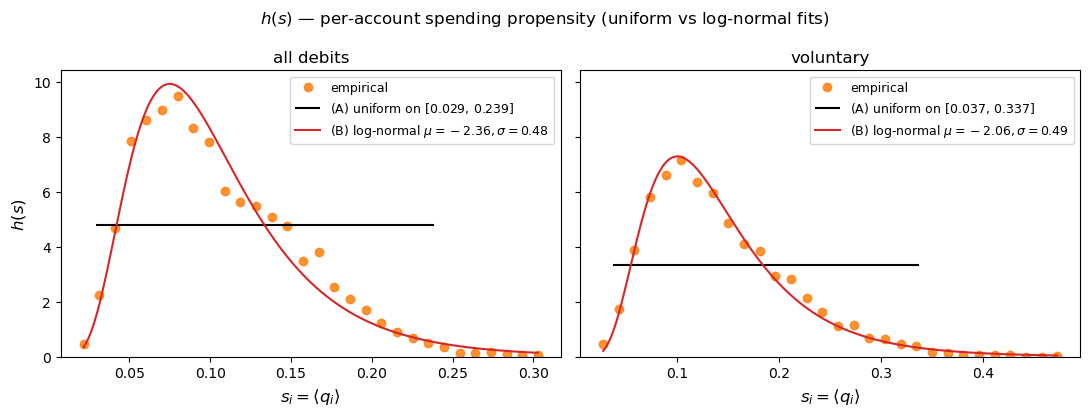

In [11]:
def hs_summary(values, name):
    v = np.asarray(values.dropna())
    p01, p99 = np.quantile(v, [0.01, 0.99])
    log_v = np.log(v[v > 0])
    return {
        'name': name,
        'n': len(v),
        's_mean': float(v.mean()),
        's_median': float(np.median(v)),
        's_min': float(v.min()),
        's_max': float(v.max()),
        's_min_p01': float(p01),
        's_max_p99': float(p99),
        'mu_log':    float(log_v.mean()),
        'sigma_log': float(log_v.std(ddof=1)),
    }

hs_all = hs_summary(agents['mean_frac_out_all'],       'all debits')
hs_vol = hs_summary(agents['mean_frac_out_voluntary'], 'voluntary')

for h in (hs_all, hs_vol):
    print(f"{h['name']:11s}  n={h['n']:,}  mean={h['s_mean']:.3f}  median={h['s_median']:.3f}  "
          f"[min={h['s_min']:.4f}, max={h['s_max']:.4f}]  [p01={h['s_min_p01']:.4f}, p99={h['s_max_p99']:.4f}]")
    print(f"             log-normal: mu={h['mu_log']:.3f}  sigma={h['sigma_log']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, h, col in zip(axes, [hs_all, hs_vol], ['mean_frac_out_all', 'mean_frac_out_voluntary']):
    vals = agents[col].dropna()
    centers, dens = histogram(vals, num_bins=30, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.85, color='C1', label='empirical')

    # (A) uniform on [p01, p99]
    s_lo, s_hi = h['s_min_p01'], h['s_max_p99']
    ax.hlines(1.0 / (s_hi - s_lo), s_lo, s_hi, color='k', lw=1.5,
              label=fr'(A) uniform on $[{s_lo:.3f},\,{s_hi:.3f}]$')

    # (B) log-normal parametric fit
    xs_ln = np.linspace(centers.min(), centers.max(), 200)
    pdf_ln = _lognorm_dist.pdf(xs_ln, s=h['sigma_log'], scale=np.exp(h['mu_log']))
    ax.plot(xs_ln, pdf_ln, color='C3', lw=1.5,
            label=fr"(B) log-normal $\mu={h['mu_log']:.2f}, \sigma={h['sigma_log']:.2f}$")

    ax.set_xlabel(r'$s_i = \langle q_i \rangle$')
    ax.set_title(h['name'])
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$h(s)$')
fig.suptitle(r'$h(s)$ — per-account spending propensity (uniform vs log-normal fits)')
fig.tight_layout()
save_fig('hs_distribution')


### 2.2 Within-account dispersion $\hat\xi$

The Beta-Binomial precision parameter: under $w \sim \mathrm{BetaBin}(M, \xi s, \xi(1-s))$, the per-tx fraction $q = w/M$ has $\mathrm{Var}(q\mid i) \approx s_i(1-s_i)/(\xi+1)$ (large-$M$ limit). So $\xi$ is calibrated by the slope of empirical per-account $\mathrm{Var}(q\mid i)$ against $s_i(1-s_i)$.

Two views:

1. **Within-account residuals** $r_{ij} = q_{ij} - \langle q_i \rangle$, with the variance decomposition $\mathrm{Var}(q) = \mathrm{Var}(\langle q_i \rangle) + \mathbb{E}[\mathrm{Var}(q\mid i)]$ split into between- vs within-account contributions.
2. **Direct $\hat\xi$** by moment-matching $\hat\xi = \mathbb{E}_i[s_i(1-s_i)] / \mathbb{E}_i[\mathrm{Var}(q\mid i)] - 1$, with the per-account scatter overlaid by the implied $1/(\hat\xi+1)$ slope-1 line. Sarafu calibration $\xi=1$ shown for reference.


all debits: Var(q)=0.0143  ->  between=0.0021 (14%)  within=0.0131 (86%)
voluntary : Var(q)=0.0146  ->  between=0.0039 (26%)  within=0.0114 (74%)


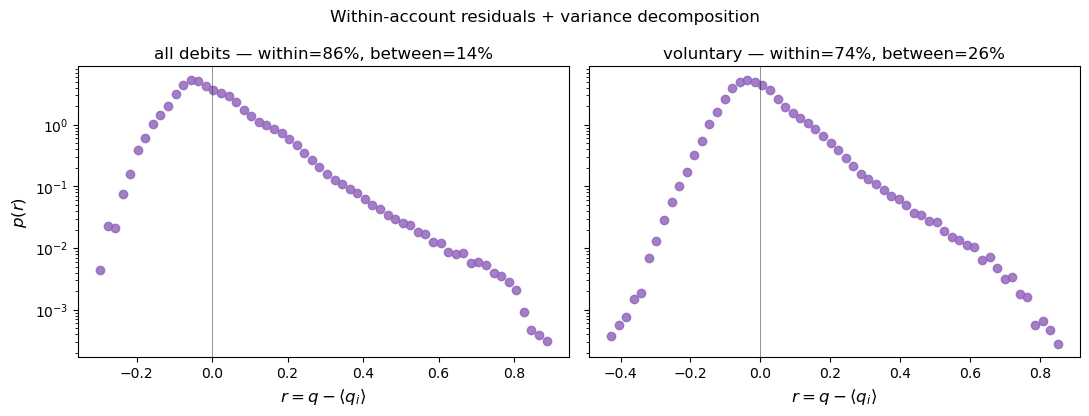

In [12]:
def residuals_and_decomp(q_series, account_ids):
    mask = q_series.notna()
    q = q_series[mask]; a = account_ids[mask]
    mean_per = q.groupby(a, observed=True).transform('mean')
    r = (q - mean_per).rename('r')
    return r, mean_per.var(), q.groupby(a, observed=True).var().mean()

q_all = tx['frac_out']
q_vol = tx['frac_out'].where(tx['voluntary'])
r_all, b_all, w_all = residuals_and_decomp(q_all, tx['account_id'])
r_vol, b_vol, w_vol = residuals_and_decomp(q_vol, tx['account_id'])
print(f"all debits: Var(q)={q_all.var():.4f}  ->  between={b_all:.4f} ({b_all/(b_all+w_all):.0%})  within={w_all:.4f} ({w_all/(b_all+w_all):.0%})")
print(f"voluntary : Var(q)={q_vol.var():.4f}  ->  between={b_vol:.4f} ({b_vol/(b_vol+w_vol):.0%})  within={w_vol:.4f} ({w_vol/(b_vol+w_vol):.0%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, r, b, w) in zip(axes, [('all debits', r_all, b_all, w_all), ('voluntary', r_vol, b_vol, w_vol)]):
    centers, dens = histogram(r, num_bins=60, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.85, color='C4')
    ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    frac_within = w / (b + w)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_title(f'{label} — within={frac_within:.0%}, between={1-frac_within:.0%}')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('Within-account residuals + variance decomposition')
fig.tight_layout()
save_fig('residuals_decomp')

# Single-panel exports (suppressed inline; saved to figs/ for sharing)
for _label, _r, _b, _w, _suf in [
    ('all debits', r_all, b_all, w_all, 'all'),
    ('voluntary',  r_vol, b_vol, w_vol, 'voluntary'),
]:
    _fig, _ax = plt.subplots(figsize=(6, 4.2))
    _c, _d = histogram(_r, num_bins=60, log_bin=False)
    _ax.plot(_c, _d, marker='o', linestyle='', alpha=0.8, color='C4')
    _ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    _frac_within = _w / (_b + _w)
    _ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    _ax.set_ylabel(r'$p(r)$')
    _ax.set_title(f'{_label} — within={_frac_within:.0%}, between={1-_frac_within:.0%}')
    _ax.set_yscale('log')
    _fig.tight_layout()
    save_fig(f'residuals_decomp_{_suf}')
    plt.close(_fig)


xi_hat (all debits) = 6.19   (4,359 accounts with n>=20)
xi_hat (voluntary)  = 9.26   (4,307 accounts with n>=20)
(Sarafu calibration: xi=1)


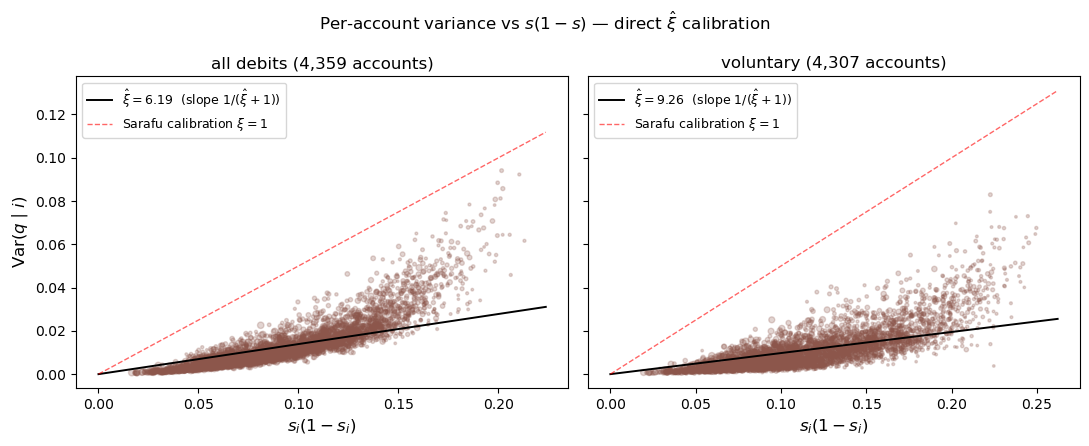

In [13]:
def per_account_moments(q_series, account_ids, min_n=20):
    mask = q_series.notna()
    g = q_series[mask].groupby(account_ids[mask], observed=True)
    df = pd.DataFrame({'s': g.mean(), 'var': g.var(ddof=1), 'n': g.size()})
    return df[df['n'] >= min_n]

def estimate_xi(per_acct):
    w = per_acct['n']
    e_s1ms = np.average(per_acct['s'] * (1 - per_acct['s']), weights=w)
    e_var  = np.average(per_acct['var'],                     weights=w)
    return float(e_s1ms / e_var - 1), float(e_s1ms), float(e_var)

pa_all = per_account_moments(q_all, tx['account_id'])
pa_vol = per_account_moments(q_vol, tx['account_id'])
xi_all, _, _ = estimate_xi(pa_all)
xi_vol, _, _ = estimate_xi(pa_vol)
print(f'xi_hat (all debits) = {xi_all:.2f}   ({len(pa_all):,} accounts with n>=20)')
print(f'xi_hat (voluntary)  = {xi_vol:.2f}   ({len(pa_vol):,} accounts with n>=20)')
print(f'(Sarafu calibration: xi=1)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, pa, xi_hat) in zip(axes, [('all debits', pa_all, xi_all), ('voluntary', pa_vol, xi_vol)]):
    x = (pa['s'] * (1 - pa['s'])).values
    y = pa['var'].values
    ax.scatter(x, y, s=2 + 0.05*pa['n'].values, alpha=0.25, color='C5')
    xs = np.linspace(0, x.max() * 1.05, 50)
    ax.plot(xs, xs / (xi_hat + 1), 'k-', lw=1.4, label=fr'$\hat\xi={xi_hat:.2f}$  (slope $1/(\hat\xi+1)$)')
    ax.plot(xs, xs / 2,            'r--', lw=1, alpha=0.6, label=r'Sarafu calibration $\xi=1$')
    ax.set_xlabel(r'$s_i(1-s_i)$')
    ax.set_title(f'{label} ({len(pa):,} accounts)')
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylabel(r'$\mathrm{Var}(q\mid i)$')
fig.suptitle(r'Per-account variance vs $s(1-s)$ — direct $\hat\xi$ calibration')
fig.tight_layout()
save_fig('xi_calibration')

# Single-panel exports
for _label, _pa, _xi, _suf in [
    ('all debits', pa_all, xi_all, 'all'),
    ('voluntary',  pa_vol, xi_vol, 'voluntary'),
]:
    _fig, _ax = plt.subplots(figsize=(6, 4.5))
    _x = (_pa['s'] * (1 - _pa['s'])).values
    _y = _pa['var'].values
    _ax.scatter(_x, _y, s=2 + 0.05*_pa['n'].values, alpha=0.25, color='C5')
    _xs = np.linspace(0, _x.max() * 1.05, 50)
    _ax.plot(_xs, _xs / (_xi + 1), 'k-', lw=1.4,
             label=fr'$\hat\xi={_xi:.2f}$  (slope $1/(\hat\xi+1)$)')
    _ax.plot(_xs, _xs / 2, 'r--', lw=1, alpha=0.6, label=r'Sarafu calibration $\xi=1$')
    _ax.set_xlabel(r'$s_i(1-s_i)$')
    _ax.set_ylabel(r'$\mathrm{Var}(q\mid i)$')
    _ax.set_title(f'{_label} ({len(_pa):,} accounts)')
    _ax.legend(loc='upper left', fontsize=9)
    _fig.tight_layout()
    save_fig(f'xi_calibration_{_suf}')
    plt.close(_fig)


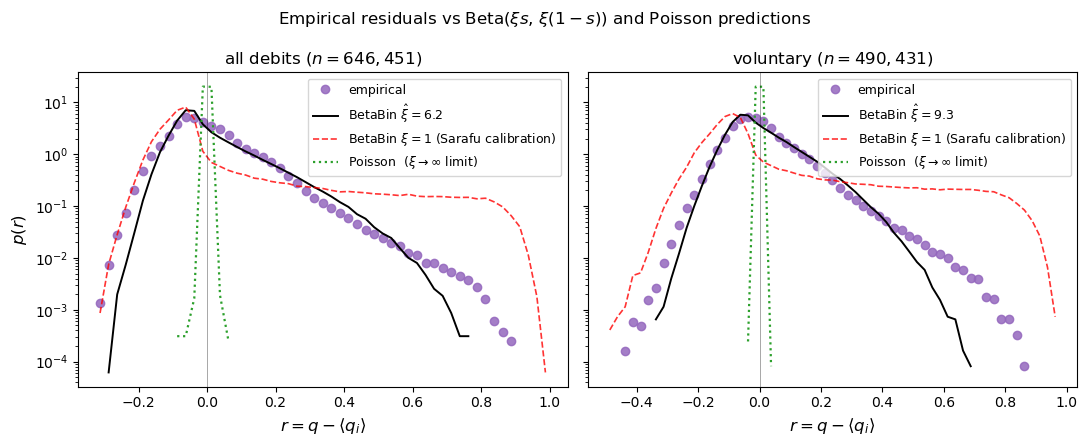

In [14]:
def simulate_residuals_beta(account_ids, s_per_account, xi, seed=42):
    s = account_ids.map(s_per_account).to_numpy()
    s = np.clip(s, 1e-4, 1 - 1e-4)
    rng = np.random.default_rng(seed)
    q = rng.beta(xi * s, xi * (1 - s))
    return q - s

def simulate_residuals_poisson(account_ids, s_per_account, m_per_tx, seed=44):
    s = account_ids.map(s_per_account).to_numpy()
    rng = np.random.default_rng(seed)
    lam = np.clip(m_per_tx * s, 0, None)
    w = rng.poisson(lam)
    return w / m_per_tx - s

cases = [
    ('all debits', q_all, agents['mean_frac_out_all'],       xi_all),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary'], xi_vol),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, q_series, s_series, xi_hat) in zip(axes, cases):
    mask = q_series.notna() & tx['account_id'].map(s_series).notna() & (tx['pre_balance'] > 0)
    aids = tx.loc[mask, 'account_id']
    m_t  = tx.loc[mask, 'pre_balance'].to_numpy()

    r_emp     = (q_series.loc[mask] - aids.map(s_series)).to_numpy()
    r_xihat   = simulate_residuals_beta(aids, s_series, xi_hat)
    r_xi1     = simulate_residuals_beta(aids, s_series, 1.0, seed=43)
    r_poisson = simulate_residuals_poisson(aids, s_series, m_t)

    edges = np.linspace(-1, 1, 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for r, lbl, kw in [
        (r_emp,     'empirical',                          dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (r_xihat,   fr'BetaBin $\hat\xi={xi_hat:.1f}$',   dict(linestyle='-',  color='k',     lw=1.4)),
        (r_xi1,     r'BetaBin $\xi=1$ (Sarafu calibration)',          dict(linestyle='--', color='r',     lw=1.2, alpha=0.8)),
        (r_poisson, r'Poisson  ($\xi\to\infty$ limit)',   dict(linestyle=':',  color='C2',    lw=1.6)),
    ]:
        d, _ = np.histogram(r, bins=edges, density=True)
        d = np.where(d > 0, d, np.nan)
        ax.plot(centers, d, label=lbl, **kw)
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_yscale('log')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle(r'Empirical residuals vs Beta($\xi s$, $\xi(1-s)$) and Poisson predictions')
fig.tight_layout()
save_fig('residuals_overlay')

# Single-panel exports
for _case, _suf in zip(cases, ['all', 'voluntary']):
    _label, _q, _s, _xi = _case
    _mask = _q.notna() & tx['account_id'].map(_s).notna() & (tx['pre_balance'] > 0)
    _aids = tx.loc[_mask, 'account_id']
    _mt   = tx.loc[_mask, 'pre_balance'].to_numpy()
    _r_emp     = (_q.loc[_mask] - _aids.map(_s)).to_numpy()
    _r_xihat   = simulate_residuals_beta(_aids, _s, _xi)
    _r_xi1     = simulate_residuals_beta(_aids, _s, 1.0, seed=43)
    _r_poisson = simulate_residuals_poisson(_aids, _s, _mt)
    _fig, _ax = plt.subplots(figsize=(6, 4.5))
    _edges = np.linspace(-1, 1, 81)
    _ctrs  = 0.5 * (_edges[:-1] + _edges[1:])
    for _arr, _lbl, _kw in [
        (_r_emp,     'empirical',                                dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (_r_xihat,   fr'BetaBin $\hat\xi={_xi:.1f}$',          dict(linestyle='-',  color='k',  lw=1.4)),
        (_r_xi1,     r'BetaBin $\xi=1$ (Sarafu calibration)',   dict(linestyle='--', color='r',  lw=1.2, alpha=0.8)),
        (_r_poisson, r'Poisson  ($\xi\to\infty$ limit)',      dict(linestyle=':',  color='C2', lw=1.6)),
    ]:
        _d, _ = np.histogram(_arr, bins=_edges, density=True)
        _d = np.where(_d > 0, _d, np.nan)
        _ax.plot(_ctrs, _d, label=_lbl, **_kw)
    _ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    _ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    _ax.set_ylabel(r'$p(r)$')
    _ax.set_yscale('log')
    _ax.set_title(f'{_label} ($n={_mask.sum():,}$)')
    _ax.legend(loc='upper right', fontsize=9)
    _fig.tight_layout()
    save_fig(f'residuals_overlay_{_suf}')
    plt.close(_fig)


### 2.3 Activity & attractiveness — degree distributions

**Asymmetric treatment** in this variant:
- **Activity** (out-side, `tx_out_rate`) — log-normal fit on per-active-month rates. Broad distribution, well-captured by lognormal.
- **Attractiveness** (in-side, `tx_in_rate` / `tx_in_vol_rate`) — **constant for all nodes**, equal to the empirical mean of `tx_in_vol_rate` (voluntary). The voluntary in-rate is sharply peaked near 1 tx/month (salary frequency), so a constant captures the bulk far more honestly than a lognormal — and it also lets us skip the copula entirely. Consistent with the Sarafu calibration.


Out-side log-normal fits (per-active-month rates):
  all transactions   out:  mu=1.202  sigma=0.287  mean=3.470  median=3.268  (n=4,361)
  voluntary          out:  mu=0.902  sigma=0.367  mean=2.637  median=2.430  (n=4,361)

In-side summary (used as constant attractivity in the simulator):
  all transactions   in :  mean=2.206  median=2.060  std=0.384  (n=4,361)
  voluntary          in :  mean=1.214  median=1.077  std=0.308  (n=4,361)


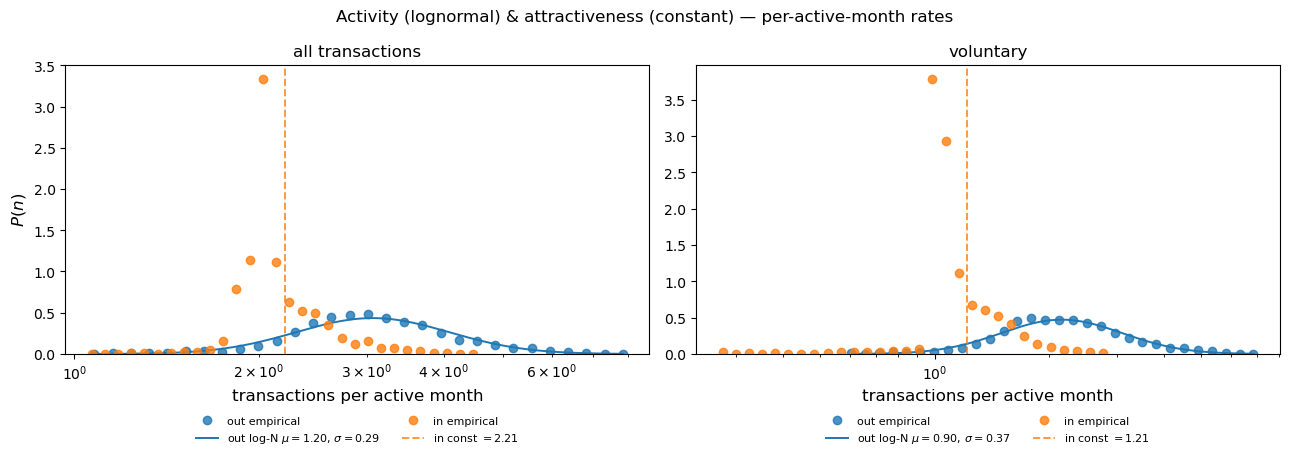

In [15]:
def fit_lognormal(vals):
    v = np.asarray(vals)
    v = v[(v > 0) & np.isfinite(v)]
    log_v = np.log(v)
    return {
        'mu': float(log_v.mean()), 'sigma': float(log_v.std(ddof=1)),
        'mean': float(v.mean()),   'median': float(np.median(v)),
        'n': int(len(v)),
    }

def plot_lognorm_marginal(ax, vals, color, label_prefix):
    vals = np.asarray(vals)
    vals = vals[(vals > 0) & np.isfinite(vals)]
    centers, dens = histogram(vals, num_bins=30, log_bin=True)
    ax.plot(centers, dens, marker='o', linestyle='', color=color, alpha=0.8,
            label=f'{label_prefix} empirical')
    f = fit_lognormal(vals)
    xs = np.geomspace(centers.min(), centers.max(), 200)
    pdf = _lognorm_dist.pdf(xs, s=f['sigma'], scale=np.exp(f['mu']))
    ax.plot(xs, pdf, color=color, lw=1.4, ls='-',
            label=fr"{label_prefix} log-N $\mu={f['mu']:.2f},\,\sigma={f['sigma']:.2f}$")
    return f

def summarise_in_side(ax, vals, color, label_prefix):
    """In-degree is modeled as a constant in the simulator. Plot the empirical histogram
    and a dashed vertical line at the mean, which is the value fed to the simulator."""
    vals = np.asarray(vals)
    vals = vals[(vals > 0) & np.isfinite(vals)]
    centers, dens = histogram(vals, num_bins=30, log_bin=True)
    ax.plot(centers, dens, marker='o', linestyle='', color=color, alpha=0.8,
            label=f'{label_prefix} empirical')
    mean_val = float(vals.mean())
    ax.axvline(mean_val, color=color, ls='--', lw=1.4, alpha=0.8,
               label=fr"{label_prefix} const $={mean_val:.2f}$")
    return {'mean': mean_val, 'median': float(np.median(vals)),
            'std': float(vals.std(ddof=1)), 'n': int(len(vals))}

deg_fits = {}
in_stats = {}
# Independent y-axes so the voluntary in-side peak isn't squashed by the wider all-tx panel.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
panels = [
    ('all transactions', 'tx_out_rate',     'tx_in_rate'),
    ('voluntary',        'tx_out_vol_rate', 'tx_in_vol_rate'),
]
for ax, (title, out_col, in_col) in zip(axes, panels):
    deg_fits[(title, 'out')] = plot_lognorm_marginal(ax, agents[out_col], 'C0', 'out')
    in_stats[(title, 'in')]  = summarise_in_side(  ax, agents[in_col],  'C1', 'in')
    ax.set_xscale('log')
    ax.set_xlabel('transactions per active month')
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    # Legend below the plot — long enough labels would clip the in-side peak dots
    # if placed inside; below is roomy and uses the empty horizontal space.
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=2, fontsize=8, frameon=False)
axes[0].set_ylabel(r'$P(n)$')
fig.suptitle('Activity (lognormal) & attractiveness (constant) — per-active-month rates')
fig.tight_layout()
save_fig('degree_marginals')

print('Out-side log-normal fits (per-active-month rates):')
for (panel, side), f in deg_fits.items():
    print(f"  {panel:18s} {side:3s}:  mu={f['mu']:.3f}  sigma={f['sigma']:.3f}  "
          f"mean={f['mean']:.3f}  median={f['median']:.3f}  (n={f['n']:,})")
print('\nIn-side summary (used as constant attractivity in the simulator):')
for (panel, side), s in in_stats.items():
    print(f"  {panel:18s} {side:3s}:  mean={s['mean']:.3f}  median={s['median']:.3f}  "
          f"std={s['std']:.3f}  (n={s['n']:,})")


### 2.4 Joint dependence — skipped (constant attractivity)

With attractiveness modeled as a constant (§2.3), there's no per-account variation in the in-direction, so no joint structure to learn between `tx_in_rate` and `tx_out_rate`. We skip the copula fit entirely.


## 3. Conditional $P(m \mid s)$

A conditional check on the balance distribution by spending rate. Bin accounts by their per-account $s_i$, plot the within-bin balance distribution, all on the same axes with one color per bin.

The NB curves shown here are **moment-matched** to each bin's empirical mean and variance — *not* derived from theory. The full theoretical comparison is part of the simulator validation in §5.


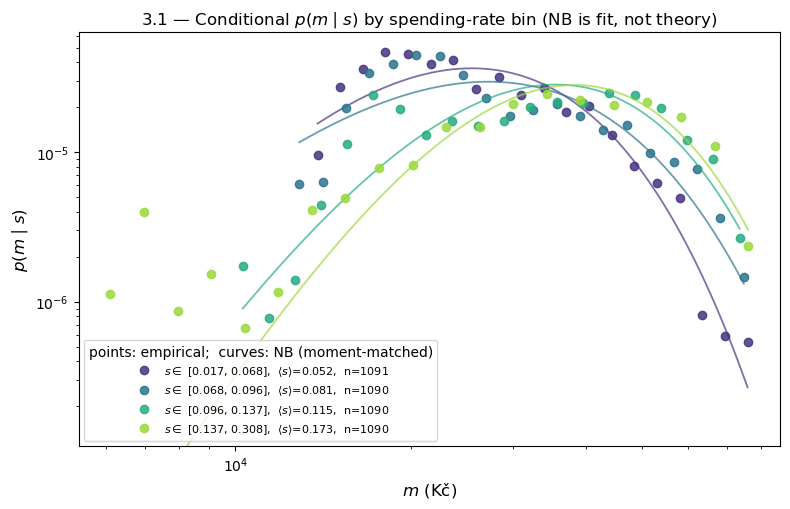

In [16]:
s_acct = agents['mean_frac_out_all']
m_acct = agents['mean_bal']
ok = s_acct.notna() & m_acct.notna() & (m_acct > 0)
s_acct, m_acct = s_acct[ok], m_acct[ok]
n_bins = 4
quantiles = np.linspace(0, 1, n_bins + 1)
edges = s_acct.quantile(quantiles).values
bin_idx = pd.cut(s_acct, edges, include_lowest=True, labels=False).astype('Int64')

fig, ax = plt.subplots(1, 1, figsize=(8, 5.2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_bins))
y_floor = 1e-7
all_dens_min = []
for k in range(n_bins):
    in_bin = bin_idx == k
    s_lo, s_hi = edges[k], edges[k+1]
    s_mean_bin = float(s_acct[in_bin].mean())
    m_vals = m_acct[in_bin].to_numpy()
    n_in = len(m_vals)
    if n_in < 30:
        continue
    centers, dens = histogram(m_vals, num_bins=20, log_bin=True)
    all_dens_min.append(dens[dens > 0].min())
    ax.plot(centers, dens, marker='o', linestyle='', color=colors[k], alpha=0.85,
            label=fr'$s \in$ [{s_lo:.3f}, {s_hi:.3f}],  $\langle s \rangle$={s_mean_bin:.3f},  n={n_in}')
    # NB curve moment-matched to bin's empirical (mean, variance) — fit, not theory.
    lam = float(m_vals.mean())
    var = float(m_vals.var(ddof=1))
    if var > lam:
        r_emp = lam ** 2 / (var - lam)
        p_emp = r_emp / (r_emp + lam)
        xs_nb = np.geomspace(max(1.0, centers.min()), centers.max(), 300)
        nb_pmf = _nbinom_dist.pmf(np.round(xs_nb).astype(int), n=r_emp, p=p_emp)
        nv = nb_pmf > y_floor
        ax.plot(xs_nb[nv], nb_pmf[nv], color=colors[k], ls='-', lw=1.3, alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(bottom=max(y_floor, min(all_dens_min) / 5))
ax.set_xlabel(r'$m$ (Kč)')
ax.set_ylabel(r'$p(m \mid s)$')
ax.legend(loc='lower left', fontsize=8, title='points: empirical;  curves: NB (moment-matched)')
ax.set_title(r'3.1 — Conditional $p(m \mid s)$ by spending-rate bin (NB is fit, not theory)')
fig.tight_layout()
save_fig('pm_by_s_bin')


### 3.2 Is $s$ independent of activity / attractiveness / inflows?

The model derivations assume $h(s)$ is independent of $P(a, b)$. Berka shows the empirical $\langle m \rangle$ *increases* with $s$ — the opposite of $\lambda_s = K_0/s$. Two possible explanations:

1. **Correlation with activity**: high-$s$ accounts also have high $a$ and/or $b$, so they get more inflows, more balance.
2. **Correlation with deposit size**: high-$s$ accounts receive larger individual deposits (e.g. salary level), so absolute balance is high even though they spend a larger *fraction* per transaction.

Cleanest test: Spearman $\rho$ of $s_i$ against $a_i$ ($\mathrm{tx}_\mathrm{out}$), $b_i$ ($\mathrm{tx}_\mathrm{in}$), mean incoming amount, and mean outgoing amount. The independence assumption requires $|\rho| \approx 0$ for the activity pair; non-zero correlations with the *amount* variables would point to (2) — and to a Berka-vs-Sarafu structural difference, since Berka's external salary inflows aren't part of a closed-system model.


Spearman correlations with s = <q_i>:
  a (tx_out_rate)            rho = -0.011
  b (tx_in_rate)             rho = +0.212
  mean amount in             rho = +0.735
  mean amount out            rho = +0.847


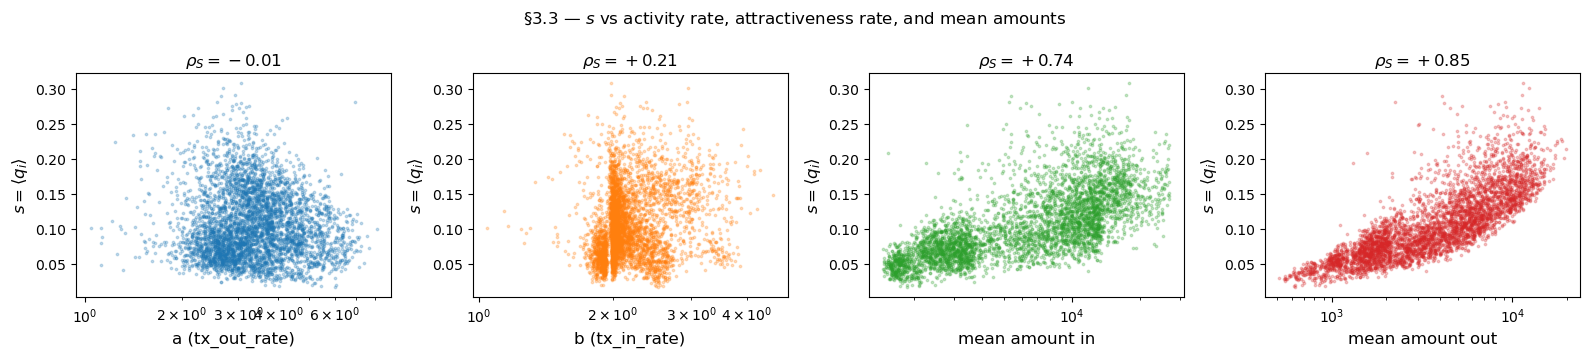

In [17]:
from scipy.stats import spearmanr

s_i = agents['mean_frac_out_all']
a_i = agents['tx_out_rate']
b_i = agents['tx_in_rate']
mean_amt_in  = (tx[tx['type'].eq('CREDIT')].groupby('account_id', observed=True)['amount']
                .mean().reindex(agents.index))
mean_amt_out = (tx[tx['type'].eq('DEBIT' )].groupby('account_id', observed=True)['amount']
                .mean().reindex(agents.index))

specs = [
    ('a (tx_out_rate)',     a_i,            'C0'),
    ('b (tx_in_rate)',      b_i,            'C1'),
    ('mean amount in',      mean_amt_in,    'C2'),
    ('mean amount out',     mean_amt_out,   'C3'),
]
print('Spearman correlations with s = <q_i>:')
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (label, vals, color) in zip(axes, specs):
    ok = vals.notna() & s_i.notna()
    rho, _ = spearmanr(vals[ok], s_i[ok])
    print(f'  {label:25s}  rho = {rho:+.3f}')
    ax.scatter(vals[ok], s_i[ok], s=3, alpha=0.25, color=color)
    ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel(r'$s = \langle q_i \rangle$')
    ax.set_title(fr'$\rho_{{S}} = {rho:+.2f}$')
fig.suptitle(r'§3.3 — $s$ vs activity rate, attractiveness rate, and mean amounts')
fig.tight_layout()
save_fig('s_correlations')


## 4. Outputs — what we want the simulator to reproduce

Each of these panels is what the simulator should be compared against. Section 5 below adds the simulator overlay under the Beta-Binomial dispersion choice. Poisson is shown throughout as the literature null.


### 4.1 $P(m)$, $P(w_\mathrm{in})$, $P(w_\mathrm{out})$ — per-event distributions

Three stylized outputs on shared log-log axes. $P(m)$ is the snapshot balance distribution (last day of observation); $P(w_\mathrm{in})$ and $P(w_\mathrm{out})$ are per-transaction amount distributions for incoming and outgoing transactions respectively.

A closed-system model implicitly assumes $P(w_\mathrm{in})=P(w_\mathrm{out})$ — every outflow is somebody else's inflow. Berka is open (external salaries etc.), so we expect divergence: in-transactions can be much larger than typical out-transactions.

Two panels:
- **all transactions** — every CREDIT (in) and every DEBIT (out)
- **voluntary** — drops Fee transactions (interest credits and service charges) from both directions

$P(m)$ is the same in both panels (balance doesn't depend on which transactions you select). Each variable has its own Poisson($\langle\cdot\rangle$) reference — the literature null, narrow by construction.


<m> snapshot = 44,718 Kč
all transactions    <w_out>=4,660 Kč   <w_in>=8,025 Kč   (in/out ratio: 1.72)
voluntary           <w_out>=6,145 Kč   <w_in>=14,530 Kč   (in/out ratio: 2.36)


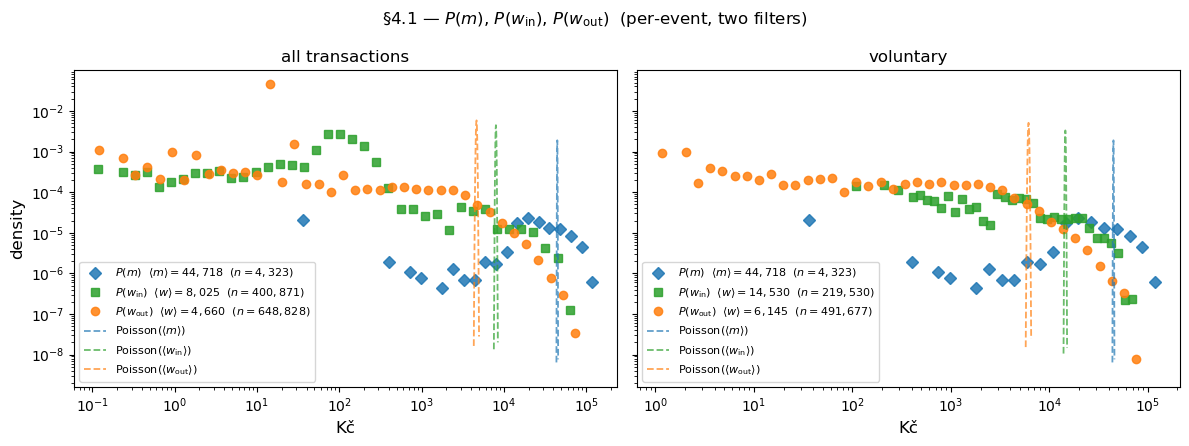

In [18]:
# §4.1 — P(m) and P(w_in) vs P(w_out), two panels (all transactions / voluntary)
def poisson_curve(lam, n=400, span=5.0):
    sig = np.sqrt(lam)
    xs = np.linspace(max(1.0, lam - span*sig), lam + span*sig, n)
    return xs, _poisson_dist.pmf(np.round(xs).astype(int), mu=lam)

# P(m): snapshot balance, last day, one value per account. Same in both panels.
m_vals = balance_pivot.iloc[:, -1].dropna().to_numpy()
m_vals = m_vals[m_vals > 0]
m_mean = float(m_vals.mean())
cm, dm = histogram(m_vals, num_bins=30, log_bin=True)

panels = [
    ('all transactions', tx['type'].eq('DEBIT'), tx['type'].eq('CREDIT')),
    ('voluntary',        tx['type'].eq('DEBIT') & tx['voluntary'],
                          tx['type'].eq('CREDIT') & tx['voluntary']),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, mask_out, mask_in) in zip(axes, panels):
    w_out = tx.loc[mask_out, 'amount'].to_numpy()
    w_in  = tx.loc[mask_in,  'amount'].to_numpy()
    w_out, w_in = w_out[w_out > 0], w_in[w_in > 0]
    wm_out, wm_in = float(w_out.mean()), float(w_in.mean())
    co, do = histogram(w_out, num_bins=40, log_bin=True)
    ci, di = histogram(w_in,  num_bins=40, log_bin=True)

    ax.plot(cm[dm>0], dm[dm>0], marker='D', linestyle='', color='C0', alpha=0.85,
            label=fr'$P(m)$  $\langle m \rangle={m_mean:,.0f}$  ($n={len(m_vals):,}$)')
    ax.plot(ci[di>0], di[di>0], marker='s', linestyle='', color='C2', alpha=0.85,
            label=fr'$P(w_\mathrm{{in}})$  $\langle w \rangle={wm_in:,.0f}$  ($n={len(w_in):,}$)')
    ax.plot(co[do>0], do[do>0], marker='o', linestyle='', color='C1', alpha=0.85,
            label=fr'$P(w_\mathrm{{out}})$  $\langle w \rangle={wm_out:,.0f}$  ($n={len(w_out):,}$)')

    xs_m, pm = poisson_curve(m_mean)
    ax.plot(xs_m, pm, color='C0', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle m \rangle$)')
    xs_i, pi = poisson_curve(wm_in)
    ax.plot(xs_i, pi, color='C2', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle w_\mathrm{in} \rangle$)')
    xs_o, po = poisson_curve(wm_out)
    ax.plot(xs_o, po, color='C1', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle w_\mathrm{out} \rangle$)')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'Kč')
    ax.set_title(label)
    floors = [d[d>0].min() for d in (dm, di, do) if (d > 0).any()]
    ax.set_ylim(bottom=max(1e-9, min(floors) / 5))
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('density')
fig.suptitle(r'§4.1 — $P(m)$, $P(w_\mathrm{in})$, $P(w_\mathrm{out})$  (per-event, two filters)')
fig.tight_layout()
save_fig('pm_pw_event')

print(f'<m> snapshot = {m_mean:,.0f} Kč')
for label, mask_out, mask_in in panels:
    print(f'{label:18s}  <w_out>={tx.loc[mask_out, "amount"].mean():,.0f} Kč   '
          f'<w_in>={tx.loc[mask_in, "amount"].mean():,.0f} Kč   '
          f'(in/out ratio: {tx.loc[mask_in, "amount"].mean()/tx.loc[mask_out, "amount"].mean():.2f})')


### 4.2 $P(\langle m \rangle)$, $P(\langle w_\mathrm{in} \rangle)$, $P(\langle w_\mathrm{out} \rangle)$ — per-account averages

Per-account averages of the §4.1 quantities, plus $\langle m \rangle$. For each account: temporal-mean balance, mean incoming amount, mean outgoing amount. Two panels (all transactions / voluntary). $\langle m \rangle$ doesn't depend on the in/out filter, so the blue squares are identical between panels.

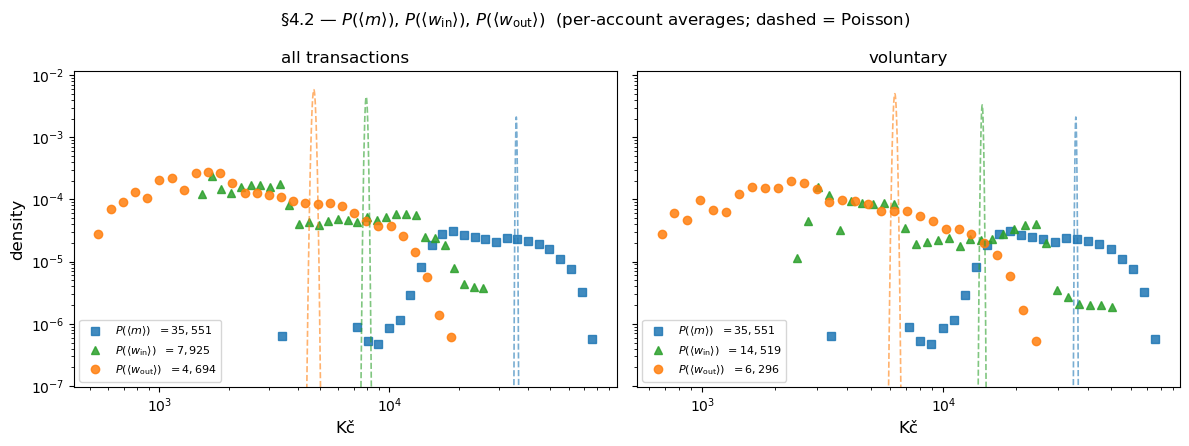

In [19]:
# §4.2 — Per-account averages: P(<m>), P(<w_in>), P(<w_out>); two panels.
m_avg = balance_pivot.mean(axis=1).dropna().to_numpy()
m_avg = m_avg[m_avg > 0]
mavg_mean = float(m_avg.mean())
cma, dma = histogram(m_avg, num_bins=30, log_bin=True)

panels = [
    ('all transactions', tx['type'].eq('DEBIT'), tx['type'].eq('CREDIT')),
    ('voluntary',        tx['type'].eq('DEBIT') & tx['voluntary'],
                          tx['type'].eq('CREDIT') & tx['voluntary']),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, mask_out, mask_in) in zip(axes, panels):
    w_out_per = (tx.loc[mask_out].groupby('account_id', observed=True)['amount']
                 .mean().dropna().to_numpy())
    w_in_per  = (tx.loc[mask_in].groupby('account_id', observed=True)['amount']
                 .mean().dropna().to_numpy())
    w_out_per = w_out_per[w_out_per > 0]
    w_in_per  = w_in_per[w_in_per > 0]
    co, do = histogram(w_out_per, num_bins=30, log_bin=True)
    ci, di = histogram(w_in_per,  num_bins=30, log_bin=True)
    wo_mean, wi_mean = float(w_out_per.mean()), float(w_in_per.mean())

    ax.plot(cma[dma>0], dma[dma>0], marker='s', linestyle='', color='C0', alpha=0.85,
            label=fr'$P(\langle m \rangle)$  $={mavg_mean:,.0f}$')
    ax.plot(ci[di>0], di[di>0], marker='^', linestyle='', color='C2', alpha=0.85,
            label=fr'$P(\langle w_\mathrm{{in}} \rangle)$  $={wi_mean:,.0f}$')
    ax.plot(co[do>0], do[do>0], marker='o', linestyle='', color='C1', alpha=0.85,
            label=fr'$P(\langle w_\mathrm{{out}} \rangle)$  $={wo_mean:,.0f}$')

    xs_m, pm = poisson_curve(mavg_mean)
    ax.plot(xs_m, pm, color='C0', ls='--', lw=1.2, alpha=0.6)
    xs_i, pi = poisson_curve(wi_mean)
    ax.plot(xs_i, pi, color='C2', ls='--', lw=1.2, alpha=0.6)
    xs_o, po = poisson_curve(wo_mean)
    ax.plot(xs_o, po, color='C1', ls='--', lw=1.2, alpha=0.6)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Kč')
    ax.set_title(label)
    floors = [d[d>0].min() for d in (dma, di, do) if (d > 0).any()]
    ax.set_ylim(bottom=max(1e-9, min(floors) / 5))
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('density')
fig.suptitle(r'§4.2 — $P(\langle m \rangle)$, $P(\langle w_\mathrm{in} \rangle)$, $P(\langle w_\mathrm{out} \rangle)$  (per-account averages; dashed = Poisson)')
fig.tight_layout()
save_fig('pm_pw_per_account')


### 4.3 Stationarity check — end-of-year $P(m)$

One snapshot $P(m)$ per year-end (1993-12-31 through 1998-12-31), all on the same axes. If Berka's balance distribution is approximately stationary, the six curves overlap. Visible drift would indicate the simulator should target a *time-varying* $P(m)$ rather than a single equilibrium.

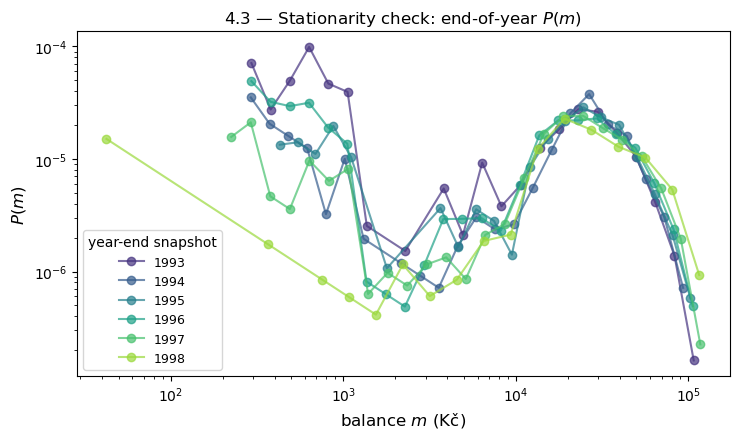

In [20]:
# Stationarity: end-of-year P(m), one curve per year overlaid.
year_ends = [pd.Timestamp(f'{y}-12-31') for y in range(1993, 1999)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(year_ends)))
for date, color in zip(year_ends, colors):
    if date not in balance_pivot.columns:
        continue
    bal = balance_pivot[date].dropna().to_numpy()
    bal = bal[bal > 0]
    if len(bal) < 30:
        continue
    c, d = histogram(bal, num_bins=25, log_bin=True)
    keep = d > 0
    ax.plot(c[keep], d[keep], marker='o', linestyle='-', alpha=0.7, color=color,
            label=str(date.year))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'balance $m$ (Kč)')
ax.set_ylabel(r'$P(m)$')
ax.legend(title='year-end snapshot', loc='lower left', fontsize=9)
ax.set_title('4.3 — Stationarity check: end-of-year $P(m)$')
fig.tight_layout()
save_fig('pm_stationarity')


### 4.4 $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ joint scatter — output

Per-account in- vs. out-**degree**. The same data whose marginals appeared in §2.3 (as inputs to the simulator) now displayed as the joint pattern that the simulator's output should reproduce.

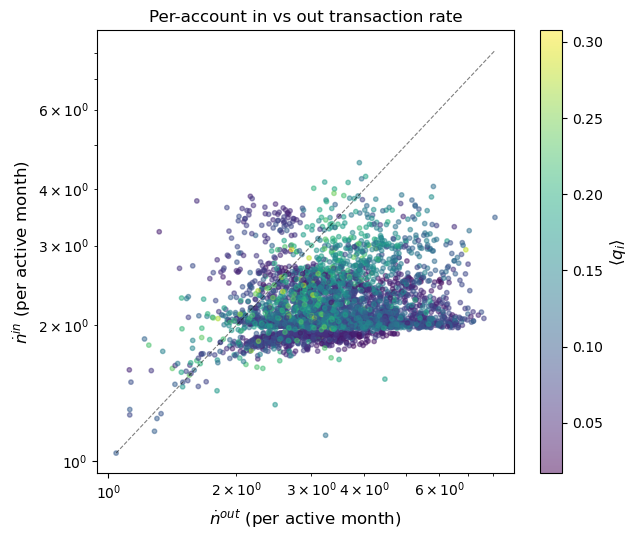

In [21]:
a = agents[(agents['tx_in_rate'] > 0) & (agents['tx_out_rate'] > 0)].copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(a['tx_out_rate'], a['tx_in_rate'],
                c=a['mean_frac_out_all'].fillna(a['mean_frac_out_all'].median()),
                s=10, cmap='viridis', alpha=0.5)
lo = max(a['tx_out_rate'].min(), a['tx_in_rate'].min())
hi = max(a['tx_out_rate'].max(), a['tx_in_rate'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\dot n^{out}$ (per active month)'); ax.set_ylabel(r'$\dot n^{in}$ (per active month)')
ax.set_title('Per-account in vs out transaction rate')
plt.colorbar(sc, ax=ax, label=r'$\langle q_i \rangle$')
fig.tight_layout()
save_fig('txin_txout_scatter')


### 4.5 $(\mathrm{vol}_\mathrm{in}, \mathrm{vol}_\mathrm{out})$ joint scatter

Per-account in vs. out **strength**. Coloring by $\langle q_i \rangle$ shows that the spending-fraction structure inferred from §2.2 also organizes the strength scatter. The simulator should reproduce both the marginal distributions of $\mathrm{vol}_\mathrm{in}$, $\mathrm{vol}_\mathrm{out}$ and their joint structure (the latter via the copula calibration in §2.4).

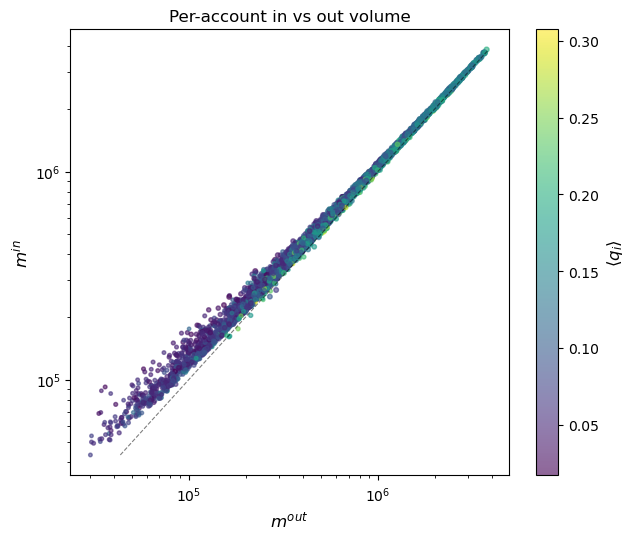

In [22]:
a = agents[(agents['vol_in'] > 0) & (agents['vol_out'] > 0)].copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(a['vol_out'], a['vol_in'],
                c=a['mean_frac_out_all'].fillna(a['mean_frac_out_all'].median()),
                s=4 + 0.5 * np.sqrt(a['tx_out'].clip(lower=1)),
                cmap='viridis', alpha=0.6)
lo = max(a['vol_out'].min(), a['vol_in'].min())
hi = max(a['vol_out'].max(), a['vol_in'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$m^{out}$'); ax.set_ylabel(r'$m^{in}$')
ax.set_title('Per-account in vs out volume')
plt.colorbar(sc, ax=ax, label=r'$\langle q_i \rangle$')
fig.tight_layout()
save_fig('volin_volout_scatter')


### 4.6 Diagnostic: per-transaction $q = w/m$ distribution

Closes the loop on the inputs → outputs flow. The simulator's $\xi$ governs how broad this distribution is for each account; aggregating over accounts gives the population $p(q)$ shown here. Under the Poisson null this would be approximately a delta at each account's $s_i$ — i.e., $p(q) \approx h(s)$ — so the empirical broadening *beyond* $h(s)$ is what $\xi$ controls.

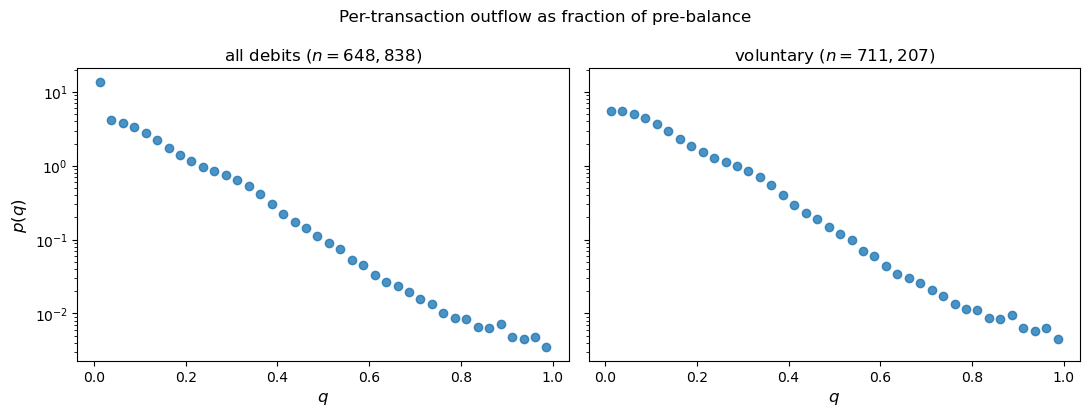

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, mask) in zip(axes, [
    ('all debits', tx['type'].eq('DEBIT')),
    ('voluntary',  tx['voluntary']),
]):
    centers, dens = histogram(tx.loc[mask, 'frac_out'], num_bins=40, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.8, color='C0')
    ax.set_xlabel(r'$q$')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(q)$')
fig.suptitle('Per-transaction outflow as fraction of pre-balance')
fig.tight_layout()
save_fig('q_distribution')


## 5. Simulator validation — Beta-Binomial transactions

Now we run the simulator under the Beta-Binomial dispersion choice ($w \sim \mathrm{BetaBin}(M, \xi s, \xi(1-s))$ with $\hat\xi$ from §2.2) and compare its outputs to the Berka empirical $P(m)$ and $P(w)$. Two checks:

- **5.1** Empirical $P(m)$ and $P(w)$ vs simulator on shared axes.
- **5.2** Data-driven bootstrap: for every Berka voluntary debit, draw $q$ from $\mathrm{Beta}(\hat\xi s_i, \hat\xi(1-s_i))$ at the empirical $s_i$ for that account and form $w = q \cdot m_i$ at the empirical mean balance. This bypasses $h(s)$, $h(a, b)$ entirely — the dispersion choice is the only model knob.

Per-node $(s, a, b)$ are drawn from the empirical voluntary-debit fits (lognormal marginals from §2.1, §2.3; Archimedean copula from §2.4). The simulator entry point is `src.model.transact`.


In [24]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src import model

# Calibration values for the simulator:
#  - h(s) and xi: unchanged from the count-variant notebook (don't depend on activity).
#  - Activity (out-side):  lognormal on per-active-month rates, converted by -log(30) so
#    the simulator gets a per-day rate parameter.
#  - Attractivity (in-side): CONSTANT for all nodes — the empirical mean of `tx_in_vol_rate`
#    (voluntary) divided by 30 to get a per-day rate. No copula to fit.
XI         = 9.26                                       # §2.2 (voluntary)
HS_LOGN    = dict(mu=-2.065, sigma=0.486)               # §2.1 (voluntary)
MEAN_BAL_BERKA = 36_905

_DAYS_PER_MONTH = 30.0
A_LOGN = dict(
    mu=deg_fits[('voluntary', 'out')]['mu'] - np.log(_DAYS_PER_MONTH),
    sigma=deg_fits[('voluntary', 'out')]['sigma'],
)
B_CONST_DAY = in_stats[('voluntary', 'in')]['mean'] / _DAYS_PER_MONTH

print(f"A_LOGN (out, per-day) = mu={A_LOGN['mu']:.3f}, sigma={A_LOGN['sigma']:.3f}")
print(f"B_CONST (in,  per-day) = {B_CONST_DAY:.4f}  "
      f"(voluntary in-rate mean = {in_stats[('voluntary', 'in')]['mean']:.3f}/month)")

N_SIM, T_SIM = 500, 200_000
print(f'Simulator: N={N_SIM} nodes, T={T_SIM:,} transactions, init_bal={MEAN_BAL_BERKA:,} Kč')

def run_simulation_at_scale(init_bal, dispersion_kw, seed=42):
    rng = np.random.default_rng(seed)
    s_per_node = rng.lognormal(mean=HS_LOGN['mu'], sigma=HS_LOGN['sigma'], size=N_SIM)
    s_per_node = np.clip(s_per_node, 1e-4, 0.999)
    # No copula — activity drawn independently; attractivity is constant.
    unif_a = rng.uniform(0.0, 1.0, size=N_SIM)
    a_per_node = _lognorm_dist.ppf(unif_a, s=A_LOGN['sigma'], scale=np.exp(A_LOGN['mu']))
    b_per_node = np.full(N_SIM, B_CONST_DAY)

    nodes = model.create_nodes(N=N_SIM,
                               activity=a_per_node.tolist(),
                               attractivity=b_per_node.tolist(),
                               spending=s_per_node.tolist(),
                               mean_iet=1.0)
    trans = model.build_target_sampler(nodes)
    acts  = model.initialize_activations(nodes, rng=rng)
    bals  = model.initialize_balances(nodes,
                                      balances=np.full(N_SIM, init_bal),
                                      decimals=0)
    amts = np.empty(T_SIM)
    for i in range(T_SIM):
        out = model.transact(nodes, acts, trans, bals, rng=rng, **dispersion_kw)
        amts[i] = float(out['amount'])
    final_bal = np.array([float(bals[k]) for k in range(N_SIM)])
    return dict(amts=amts, final_bal=final_bal,
                s_per_node=s_per_node, a_per_node=a_per_node, b_per_node=b_per_node)

print(f'\nRunning Beta-Binomial simulator (xi={XI})...')
sim_bb = run_simulation_at_scale(MEAN_BAL_BERKA, dict(xi=XI), seed=42)
print(f"  median(s)={np.median(sim_bb['s_per_node']):.3f},"
      f" mean(w)={sim_bb['amts'].mean():,.0f},"
      f" mean(m)={sim_bb['final_bal'].mean():,.0f},"
      f" std(m)/mean(m)={sim_bb['final_bal'].std()/sim_bb['final_bal'].mean():.2f}")

# xi -> infinity limit: no overdispersion. `transact` with no `s` kwarg falls through
# to `pay_share` (deterministic for continuous balances; Binomial for discrete).
print(f'\nRunning no-dispersion simulator (xi=inf)...')
sim_inf = run_simulation_at_scale(MEAN_BAL_BERKA, dict(), seed=42)
print(f"  mean(w)={sim_inf['amts'].mean():,.0f},"
      f" mean(m)={sim_inf['final_bal'].mean():,.0f},"
      f" std(m)/mean(m)={sim_inf['final_bal'].std()/sim_inf['final_bal'].mean():.2f}")

A_LOGN (out, per-day) = mu=-2.499, sigma=0.367
B_CONST (in,  per-day) = 0.0405  (voluntary in-rate mean = 1.214/month)
Simulator: N=500 nodes, T=200,000 transactions, init_bal=36,905 Kč

Running Beta-Binomial simulator (xi=9.26)...
  median(s)=0.127, mean(w)=3,674, mean(m)=36,905, std(m)/mean(m)=0.82

Running no-dispersion simulator (xi=inf)...
  mean(w)=3,659, mean(m)=36,905, std(m)/mean(m)=0.74


### 5.1 $P(m)$ and $P(w)$: Berka empirical vs simulator

Per-account mean balance $\langle m \rangle$ (empirical) vs simulator final-balance histogram, plus voluntary-debit per-tx amounts $w$ (empirical) vs simulator per-tx amount histogram, all on shared log-log axes (Kč).


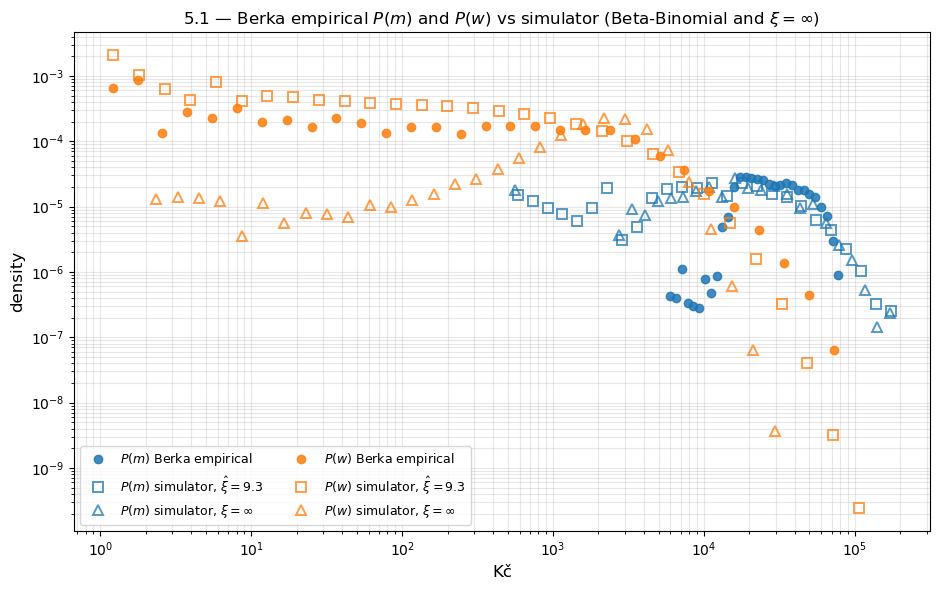

Empirical: <m>=37,029 Kč across 4,361 accounts; <w>=6,145 Kč across 491,677 voluntary debits
BB sim (9.3): mean(m)=36,905 Kč, mean(w)=3,674 Kč
xi=inf sim    : mean(m)=36,905 Kč, mean(w)=3,659 Kč


In [25]:
emp_m = agents['mean_bal'].dropna()
emp_m = emp_m[emp_m > 0]
voluntary_debits = tx['voluntary'] & tx['type'].eq('DEBIT')
emp_w = tx.loc[voluntary_debits, 'amount']
emp_w = emp_w[emp_w > 0]

c_emp_m, d_emp_m = histogram(emp_m, num_bins=30, log_bin=True)
c_emp_w, d_emp_w = histogram(emp_w, num_bins=30, log_bin=True)
c_bb_m,  d_bb_m  = histogram(sim_bb['final_bal'],  num_bins=30, log_bin=True)
c_bb_w,  d_bb_w  = histogram(sim_bb['amts'],       num_bins=30, log_bin=True)
c_inf_m, d_inf_m = histogram(sim_inf['final_bal'], num_bins=30, log_bin=True)
c_inf_w, d_inf_w = histogram(sim_inf['amts'],      num_bins=30, log_bin=True)

fig, ax = plt.subplots(figsize=(9.5, 6))
# P(m) — three series
ax.plot(c_emp_m[d_emp_m>0], d_emp_m[d_emp_m>0], 'o',  color='C0', alpha=0.85, ms=6,
        label=r'$P(m)$ Berka empirical')
ax.plot(c_bb_m[d_bb_m>0],   d_bb_m[d_bb_m>0],   's',  color='C0', alpha=0.75, ms=7,
        markerfacecolor='none', markeredgewidth=1.4,
        label=fr'$P(m)$ simulator, $\hat\xi={XI:.1f}$')
ax.plot(c_inf_m[d_inf_m>0], d_inf_m[d_inf_m>0], '^',  color='C0', alpha=0.75, ms=7,
        markerfacecolor='none', markeredgewidth=1.4,
        label=r'$P(m)$ simulator, $\xi=\infty$')
# P(w) — three series
ax.plot(c_emp_w[d_emp_w>0], d_emp_w[d_emp_w>0], 'o',  color='C1', alpha=0.85, ms=6,
        label=r'$P(w)$ Berka empirical')
ax.plot(c_bb_w[d_bb_w>0],   d_bb_w[d_bb_w>0],   's',  color='C1', alpha=0.75, ms=7,
        markerfacecolor='none', markeredgewidth=1.4,
        label=fr'$P(w)$ simulator, $\hat\xi={XI:.1f}$')
ax.plot(c_inf_w[d_inf_w>0], d_inf_w[d_inf_w>0], '^',  color='C1', alpha=0.75, ms=7,
        markerfacecolor='none', markeredgewidth=1.4,
        label=r'$P(w)$ simulator, $\xi=\infty$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Kč')
ax.set_ylabel('density')
ax.set_title(r'5.1 — Berka empirical $P(m)$ and $P(w)$ vs simulator (Beta-Binomial and $\xi=\infty$)')
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
save_fig('pmpw_berka_betabin')
plt.show()
print(f'Empirical: <m>={emp_m.mean():,.0f} Kč across {len(emp_m):,} accounts;'
      f' <w>={emp_w.mean():,.0f} Kč across {len(emp_w):,} voluntary debits')
print(f'BB sim ({XI:.1f}): mean(m)={sim_bb["final_bal"].mean():,.0f} Kč,'
      f' mean(w)={sim_bb["amts"].mean():,.0f} Kč')
print(f'xi=inf sim    : mean(m)={sim_inf["final_bal"].mean():,.0f} Kč,'
      f' mean(w)={sim_inf["amts"].mean():,.0f} Kč')


### 5.2 Data-driven $P(w)$: bootstrap from empirical $(m, s)$

For *each* Berka voluntary debit, look up the empirical $(s_i, m_i)$ for that account, draw $q \sim \mathrm{Beta}(\hat\xi s_i, \hat\xi(1-s_i))$, set $w = q \cdot m_i$. Compare the synthetic distribution to the empirical $P(w)$.

This bypasses $h(s)$ and $h(a, b)$ — the empirical $(s, m)$ joint *is* the distribution. The dispersion choice is the only model knob.


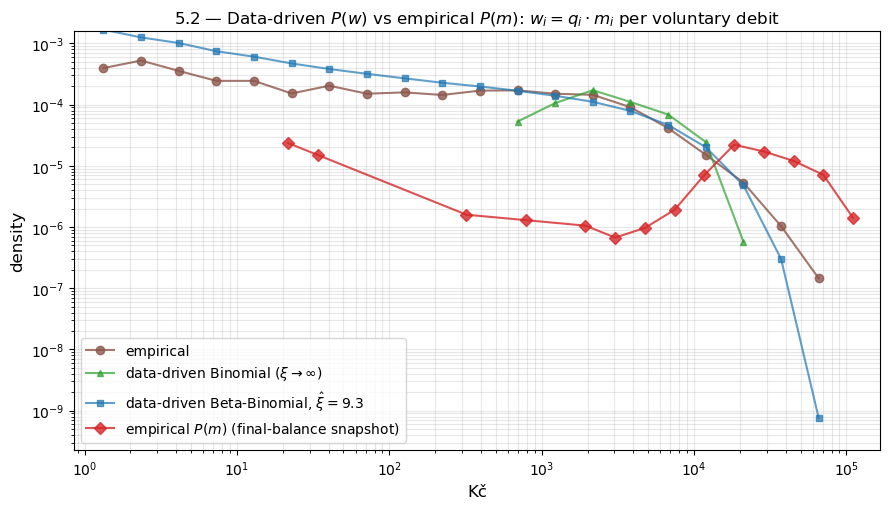


  bootstrap base : 491,677 voluntary debits with valid (s, m)
  median(w):  empirical=3,300  Binomial=4,464  Beta-Binomial=3,510
  mean(w)  :  empirical=6,145  Binomial=5,431  Beta-Binomial=5,424


In [26]:
def _hist_at(values, bins):
    v = np.asarray(values); v = v[(v > 0) & np.isfinite(v)]
    counts, _ = np.histogram(v, bins=bins, density=True)
    return counts

sb = tx.loc[voluntary_debits, ['account_id', 'amount']].merge(
    agents[['mean_frac_out_voluntary', 'mean_bal']],
    left_on='account_id', right_index=True, how='left',
)
ok = (sb['mean_bal'] > 0) & sb['mean_frac_out_voluntary'].between(1e-4, 0.999, inclusive='neither')
sb = sb.loc[ok].reset_index(drop=True)

s_arr = sb['mean_frac_out_voluntary'].to_numpy()
m_arr = sb['mean_bal'].to_numpy()
w_emp = sb['amount'].to_numpy()

rng = np.random.default_rng(2026)
# Beta-Binomial: q ~ Beta(ξ s, ξ(1-s)), so w = q · m carries within-account dispersion ∝ 1/(ξ+1)
q_bb = rng.beta(XI * s_arr, XI * (1 - s_arr))
w_bb_pred = q_bb * m_arr
# Binomial counterfactual (ξ → ∞): no within-account dispersion, only the m·s(1-s) Bernoulli noise
m_int = np.maximum(1, np.round(m_arr).astype(np.int64))
s_clip = np.clip(s_arr, 1e-10, 1 - 1e-10)
w_bin_pred = rng.binomial(m_int, s_clip).astype(float)

w_emp_pos = w_emp[w_emp > 0]
w_bins = np.geomspace(w_emp_pos.min(), w_emp_pos.max(), 21)
w_cent = np.sqrt(w_bins[:-1] * w_bins[1:])

d_emp   = _hist_at(w_emp,     w_bins)
d_bb_pr  = _hist_at(w_bb_pred,  w_bins)
d_bin_pr = _hist_at(w_bin_pred, w_bins)
# Empirical final-balance distribution (end-of-window snapshot, per-account)
m_vals = balance_pivot.iloc[:, -1].dropna().to_numpy()
m_vals = m_vals[m_vals > 0]
m_bins = np.geomspace(m_vals.min(), m_vals.max(), 21)
m_cent = np.sqrt(m_bins[:-1] * m_bins[1:])
d_emp_m = _hist_at(m_vals, m_bins)

fig, ax = plt.subplots(1, 1, figsize=(9, 5.2))
ax.plot(w_cent[d_emp>0],   d_emp[d_emp>0],   'o-', color='C5', alpha=0.8, ms=6, label='empirical')
ax.plot(w_cent[d_bin_pr>0], d_bin_pr[d_bin_pr>0], '^-', color='C2', alpha=0.7, ms=5,
        label=r'data-driven Binomial ($\xi \to \infty$)')
ax.plot(w_cent[d_bb_pr>0], d_bb_pr[d_bb_pr>0], 's-', color='C0', alpha=0.7, ms=5,
        label=fr'data-driven Beta-Binomial, $\hat\xi={XI:.1f}$')
ax.plot(m_cent[d_emp_m>0], d_emp_m[d_emp_m>0], 'D-', color='C3', alpha=0.8, ms=6,
        label='empirical $P(m)$ (final-balance snapshot)')
ax.set_xscale('log'); ax.set_yscale('log')
x_lo = min(w_bins.min(), m_bins.min()) * 0.85
x_hi = max(w_bins.max(), m_bins.max()) * 1.2
ax.set_xlim(x_lo, x_hi)
pos_mins = [a[a>0].min() for a in [d_emp, d_bb_pr, d_bin_pr, d_emp_m] if (a>0).any()]
ax.set_ylim(max(min(pos_mins), 1e-12) * 0.3, d_emp.max() * 3)
ax.set_xlabel('Kč'); ax.set_ylabel('density')
ax.set_title(r'5.2 — Data-driven $P(w)$ vs empirical $P(m)$: $w_i = q_i \cdot m_i$ per voluntary debit')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
save_fig('pw_bootstrap_betabin'); plt.show()

print(f'\n  bootstrap base : {len(sb):,} voluntary debits with valid (s, m)')
print(f'  median(w):  empirical={np.median(w_emp):,.0f}  '
      f'Binomial={np.median(w_bin_pred):,.0f}  Beta-Binomial={np.median(w_bb_pred):,.0f}')
print(f'  mean(w)  :  empirical={np.mean(w_emp):,.0f}  '
      f'Binomial={np.mean(w_bin_pred):,.0f}  Beta-Binomial={np.mean(w_bb_pred):,.0f}')


## 6. Calibration summary

Single-cell printout of the numbers a simulation task should consume.


In [27]:
# --- Aggregate observables ---
N_accounts        = int(agents.shape[0])
total_balance_Kc  = float(balance_pivot.sum(axis=0).mean())   # daily-mean total balance
mean_tx_per_acct  = float(agents['tx_out'].mean())
mean_tx_rate      = float(agents['tx_out_rate'].mean())
days_obs          = int(balance_pivot.shape[1])
mean_amount_Kc    = float(tx['amount'].mean())
mean_months_active = float(agents['months_active'].mean())

print('=' * 78)
print('BERKA — simulator calibration summary')
print('       (per-active-month rate variant, constant attractivity, no copula)')
print('=' * 78)
print('Population & system size')
print(f'  N (accounts)                          : {N_accounts:,}')
print(f'  Observation window                    : {days_obs:,} days ({days_obs/365.25:.2f} yr)')
print(f'  Mean active span per account          : {mean_months_active:.2f} months')
print(f'  Total balance in system (daily mean)  : {total_balance_Kc:,.0f} Kč')
print(f'  Mean per-tx amount <w>                : {mean_amount_Kc:,.0f} Kč')
print(f"  Mean per-account balance <m>          : {agents['mean_bal'].mean():,.0f} Kč")
print()
print('Activity & flow')
print(f"  Mean DEBITs per account (total)       : {mean_tx_per_acct:.1f}")
print(f"  Mean DEBITs per active month          : {mean_tx_rate:.2f}")
print(f"  Total DEBITs                          : {int(agents['tx_out'].sum()):,}")
print(f"  Total DEBIT volume                    : {agents['vol_out'].sum():,.0f} Kč")
print()
print('Spending propensity h(s) — three options')
print(f"  uniform [s_min, s_max]:")
print(f"    all debits      : [{hs_all['s_min_p01']:.4f}, {hs_all['s_max_p99']:.4f}]   mean={hs_all['s_mean']:.3f}")
print(f"    voluntary       : [{hs_vol['s_min_p01']:.4f}, {hs_vol['s_max_p99']:.4f}]   mean={hs_vol['s_mean']:.3f}")
print(f"  log-normal (mu, sigma):")
print(f"    all debits      : ({hs_all['mu_log']:.3f}, {hs_all['sigma_log']:.3f})")
print(f"    voluntary       : ({hs_vol['mu_log']:.3f}, {hs_vol['sigma_log']:.3f})")
print()
print('Beta-Binomial precision xi (variance moment-match)')
print(f'  all debits      : xi_hat = {xi_all:.2f}   ({len(pa_all):,} accounts with n>=20)')
print(f'  voluntary       : xi_hat = {xi_vol:.2f}   ({len(pa_vol):,} accounts with n>=20)')
print('  (Sarafu calibration in paper: xi=1)')
print()
print('Activity (out-side): log-normal on per-active-month rates')
DAYS_PER_MONTH = 30.0
for (panel, side), d in deg_fits.items():
    mu_day = d['mu'] - np.log(DAYS_PER_MONTH)
    print(f"  {panel:18s} {side:3s}: mu_rate_month={d['mu']:.3f}, sigma={d['sigma']:.3f}   "
          f"per-day rate: LogNormal(mu={mu_day:.3f}, sigma={d['sigma']:.3f})")
print()
print('Attractivity (in-side): CONSTANT (mean of empirical per-month rate)')
for (panel, side), s in in_stats.items():
    b_day = s['mean'] / DAYS_PER_MONTH
    print(f"  {panel:18s} {side:3s}: const_month={s['mean']:.3f}   "
          f"per-day rate = {b_day:.4f}   (median={s['median']:.3f}, std={s['std']:.3f})")
print()
print('Joint dependence: none — attractivity is constant, no copula needed.')
print('=' * 78)


BERKA — simulator calibration summary
       (per-active-month rate variant, constant attractivity, no copula)
Population & system size
  N (accounts)                          : 4,361
  Observation window                    : 2,191 days (6.00 yr)
  Mean active span per account          : 41.67 months
  Total balance in system (daily mean)  : 89,914,718 Kč
  Mean per-tx amount <w>                : 5,945 Kč
  Mean per-account balance <m>          : 37,029 Kč

Activity & flow
  Mean DEBITs per account (total)       : 148.8
  Mean DEBITs per active month          : 3.47
  Total DEBITs                          : 648,838
  Total DEBIT volume                    : 3,023,848,358 Kč

Spending propensity h(s) — three options
  uniform [s_min, s_max]:
    all debits      : [0.0293, 0.2388]   mean=0.105
    voluntary       : [0.0368, 0.3372]   mean=0.142
  log-normal (mu, sigma):
    all debits      : (-2.362, 0.478)
    voluntary       : (-2.064, 0.486)

Beta-Binomial precision xi (variance moment